# Donghang Zou's UChicago ADS Code Sample

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship

### 1. Motivation and data

Chronic disease burden varies across U.S. counties, and its social correlates can guide public health resources. The full project combines CDC PLACES 2021 to 2025 with CDC SVI 2020 and 2022, cleans and stacks a county panel, measures social and behavioral associations with diabetes and hypertension, and maps K-means profiles. Food, housing, and transportation insecurity are the strongest diabetes correlates (r of 0.937, 0.921, and 0.914). This short excerpt shows the pipeline on the latest snapshot; the full code and analysis are in the GitHub repository linked above.

### 2. Setup and loading the data

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as MplPath
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd().parent if Path.cwd().name == 'code_sample' else Path.cwd()
RAW, OUT = ROOT / 'data/raw', ROOT / 'code_sample'
outcomes = ['DIABETES', 'BPHIGH']
factor_labels = {'LPA': 'Inactivity', 'OBESITY': 'Obesity', 'CSMOKING': 'Smoking',
    'ACCESS2': 'Uninsured', 'DEPRESSION': 'Depression', 'SLEEP': 'Short sleep',
    'BINGE': 'Binge drinking', 'RPL_THEMES': 'Overall SVI', 'RPL_THEME1': 'SVI: socioeconomic',
    'RPL_THEME2': 'SVI: household', 'RPL_THEME3': 'SVI: minority',
    'RPL_THEME4': 'SVI: housing/transport', 'FOODINSECU': 'Food insecurity',
    'HOUSINSECU': 'Housing insecurity', 'LACKTRPT': 'Transport barriers', 'LONELINESS': 'Loneliness'}
factors = list(factor_labels)
svi_cols = [factor for factor in factors if factor.startswith('RPL')]
# String identifiers preserve leading zeros.
places = pd.read_csv(RAW / 'places_county_2025.csv', low_memory=False,
    dtype={'locationid': 'string', 'year': 'int16', 'data_value': 'float64'})
svi = pd.read_csv(RAW / 'svi_county_2022.csv', dtype={'FIPS': 'string'}, usecols=['FIPS', *svi_cols])
print(f'locationid: {places.locationid.dtype}; FIPS: {svi.FIPS.dtype}; data_value: {places.data_value.dtype}')

Matplotlib is building the font cache; this may take a moment.


locationid: string; FIPS: string; data_value: float64


### 3. Building the county snapshot



In [3]:
def prepare_county_snapshot(places, svi):
    health = places.loc[(places.stateabbr != 'US') &
                       (places.data_value_type == 'Age-adjusted prevalence')].copy()
    health['FIPS'] = health.locationid.str.zfill(5)
    health = health.sort_values('year').drop_duplicates(['FIPS', 'measureid'], keep='last')
    wide = health.pivot(index='FIPS', columns='measureid', values='data_value')
    svi = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan).set_index('FIPS')
    # Treat -999 as missing; validate raises an error for duplicate county identifiers.
    return wide.join(svi, validate='one_to_one').dropna(subset=[*outcomes, 'RPL_THEMES'])
counties = prepare_county_snapshot(places, svi)

### 4. Measuring associations

Pearson r measures association; pairwise uses available counties, while common holds the sample fixed.

In [4]:
def compare_correlations(data, outcome, factors, sample_policy='pairwise'):
    values = data[[outcome, *factors]].dropna(subset=[outcome])
    if sample_policy == 'common':
        values = values.dropna()
    return pd.DataFrame({'r': values[factors].corrwith(values[outcome]), 'n': values[factors].count()})
results = {outcome: compare_correlations(counties, outcome, factors) for outcome in outcomes}
correlations = pd.DataFrame({outcome: result.r for outcome, result in results.items()})
shown = ['FOODINSECU', 'HOUSINSECU', 'LACKTRPT', 'LPA']
common = compare_correlations(counties, 'DIABETES', shown, 'common')
paired = results['DIABETES'].loc[shown]
comparison = paired.join(common, lsuffix='_pair', rsuffix='_common')
comparison.to_csv(OUT / 'tables/correlation_summary.csv')
print(comparison.round(3).rename_axis(None))

            r_pair  n_pair  r_common  n_common
FOODINSECU   0.937    2299     0.937      2299
HOUSINSECU   0.921    2299     0.921      2299
LACKTRPT     0.914    2299     0.914      2299
LPA          0.873    2956     0.850      2299


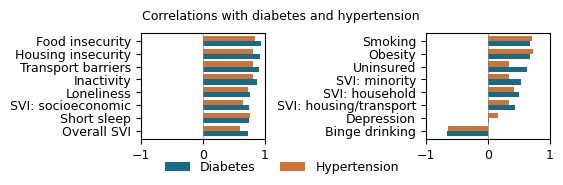

In [5]:
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 9, 'figure.titlesize': 9})
def plot_correlations(correlations):
    ranked = correlations.sort_values('DIABETES', ascending=False).rename(index=factor_labels)
    fig, axes = plt.subplots(1, 2, figsize=(5.6, 1.75))
    for ax, start in zip(axes, [0, 8]):
        ranked.iloc[start:start + 8].iloc[::-1].plot.barh(ax=ax, width=.8,
            color=['#176b87', '#cd743b'], legend=False)
        ax.set(xlim=(-1, 1), xticks=[-1, 0, 1], xlabel='', ylabel='')
        ax.axvline(0, color='grey', linewidth=.5)
    fig.suptitle('Correlations with diabetes and hypertension')
    fig.legend(axes[0].containers, ['Diabetes', 'Hypertension'], loc='lower center', ncol=2, frameon=False)
    fig.subplots_adjust(left=.25, right=.98, bottom=.24, top=.85, wspace=1.3)
    return fig
figure = plot_correlations(correlations)
figure.savefig(OUT / 'figures/fig_correlations.png', dpi=240)
plt.show()

### 5. Grouping and mapping counties

Clustering groups counties with similar disease and vulnerability profiles.

In [6]:
strength = correlations.abs().mean(axis=1).sort_values(ascending=False)
features = outcomes + strength[strength >= .40].index.tolist()
complete = counties.dropna(subset=features).copy()
# Standardize so measurement units do not determine distance.
scaled = StandardScaler().fit_transform(complete[features])
model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(scaled)
anchors = [features.index(factor) for factor in [*outcomes, 'RPL_THEMES']]
# Order tiers by mean standardized diabetes, hypertension, and SVI.
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index)
ordered_labels = labels.map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(ordered_labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(complete):,} clustered counties; silhouette = {silhouette_score(scaled, model.labels_):.3f}')
print(summary[['counties']].T.rename_axis(None, axis=1).to_string())

2,299 clustered counties; silhouette = 0.203
          Low  Moderate  High  Highest
counties  765       788   508      238


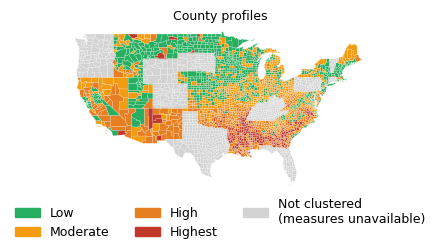

In [7]:
def plot_county_profiles(complete):
    colors = dict(zip(tiers, ['#27ae60', '#f39c12', '#e67e22', '#c0392b']))
    lookup = complete.tier.astype('string').map(colors).to_dict()
    geo = json.loads((ROOT / 'data/processed/us_counties.geojson').read_text())
    fig, ax = plt.subplots(figsize=(5.6, 2.4))
    visible = [county for county in geo['features'] if county['id'][:2] not in {'02', '15', '72'}]
    for county in visible:
        fips, geometry = county['id'], county['geometry']
        polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
        for polygon in polygons:
            rings = [MplPath(ring, closed=True) for ring in polygon]
            shape = MplPath.make_compound_path(*rings)
            ax.add_patch(PathPatch(shape, facecolor=lookup.get(fips, '#d3d3d3'), edgecolor='w', lw=.12))
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25, title='County profiles')
    ax.axis('off')
    colors['Not clustered\n(measures unavailable)'] = '#d3d3d3'
    handles = [Patch(color=color, label=tier) for tier, color in colors.items()]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
    fig.subplots_adjust(left=.02, right=.98, top=.91, bottom=.24)
    fig.savefig(OUT / 'figures/fig_risk_tier_map.png', dpi=240)
plot_county_profiles(complete)
plt.show()

Grey marks nine states missing social-needs measures (CO, FL, OR, SD, TN, TX, VT, WA, WY) and KY/PA missing diabetes and hypertension. Nine CT planning regions lack cached geometry.

### 6. Findings and limits

Sampling affects associations; higher-burden profiles cluster in the Deep South. Social-needs measures track disease burden and could help prioritize county follow-up, but this is descriptive, not causal: measurement years differ and profiles overlap.